In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf 
import scipy.sparse as sp
from recommenders.evaluation.python_evaluation import (
    map_at_k,
    ndcg_at_k,
    precision_at_k,
    recall_at_k,
)

import LightGCN
from utils import get_top_k_scored_items, nCoreReduction, user_fixed_train_test_split

import matplotlib.pyplot as plt 

import importlib 

from BatchFairnessExtend import FairnessExtendActiveLearner

# disable the SettingWithCopyWarning
pd.options.mode.chained_assignment = None

## Load data

In [2]:
data_path = "./data/ml-100k/u.data"
data_columns = ['user_id', 'item_id', 'rating', 'timestamp']

user_path = "./data/ml-100k/u.user"
user_columns = ['user_id', 'age', 'gender', 'occupation', 'zip_code']

In [3]:
data_df = pd.read_csv(data_path, sep='\t', names=data_columns, header=None)
user_df = pd.read_csv(user_path, sep='|', names=user_columns, header=None)

In [4]:
# shuffle data_df
data_df = data_df.sample(frac=1, random_state=42).reset_index(drop=True)

## Convert to implicit feedback

**Note**: For MovieLens 100k dataset, we are converting a rating in the range [1, 5] to an implicit feedback of 1 so that we still have a significant number of positive samples in the dataset. For MovieLens 1M, we could do [3, 5] instead.

We might not need this.

In [5]:
# data_df['rating'] = (data_df['rating'] >= 1).astype(int)

## Dimensionality reduction

Only keep:
- users that provided at least 5 ratings
- items that received at least 5 ratings

In [5]:
ncore_data_df = nCoreReduction(data_df)

In [6]:
print(f"The original data frame shape: {data_df.shape}")
print(f"  - # users: {data_df['user_id'].nunique()}")
print(f"  - # items: {data_df['item_id'].nunique()}")
print('\n')

print(f"The filtered data frame shape: {ncore_data_df.shape}")
print(f"  - # users: {ncore_data_df['user_id'].nunique()}")
print(f"  - # items: {ncore_data_df['item_id'].nunique()}")

The original data frame shape: (100000, 4)
  - # users: 943
  - # items: 1682


The filtered data frame shape: (99032, 4)
  - # users: 943
  - # items: 1298


## Convert id to inner id

In [7]:
unique_users = ncore_data_df['user_id'].unique()
user_id_to_iid = {id: iid for iid, id in enumerate(unique_users)}
user_iid_to_id = {iid: id for iid, id in enumerate(unique_users)}

unique_items = ncore_data_df['item_id'].unique()
item_id_to_iid = {id: iid for iid, id in enumerate(unique_items)}
item_iid_to_id = {iid: id for iid, id in enumerate(unique_items)}

In [8]:
n_users = unique_users.shape[0]
n_items = unique_items.shape[0]

In [9]:
ncore_data_df['user_iid'] = ncore_data_df['user_id'].map(user_id_to_iid)
ncore_data_df['item_iid'] = ncore_data_df['item_id'].map(item_id_to_iid)

# apply to `user_df`` as well
user_df['user_iid'] = user_df['user_id'].map(user_id_to_iid)

In [10]:
iid_to_gender = dict(zip(user_df['user_iid'], user_df['gender']))

In [11]:
n_female, n_male = user_df['gender'].value_counts()[['F', 'M']]
print(f"Number of female users: {n_female}")
print(f"Number of male users: {n_male}")

Number of female users: 273
Number of male users: 670


## Train test split (user-fixed)

In [12]:
train_df, test_df = user_fixed_train_test_split(ncore_data_df, test_size=0.2, random_state=42)

## Fairness Extend

In [13]:
# hyper-parameters

# hyper-parameter for rec sys
hparams = {
    'epochs': 50,
    'learning_rate': 0.005,
    'embed_size': 64,
    'batch_size': 1024,
    'n_layers': 3,
    'decay': 0.0001,
    'eval_epoch': -1,
    'top_k': 10,
}


n_iters = 5   # number of repeated experiments
n_epochs = 26 # epoch of active learning process
q = 50        # active learning query list size

In [ ]:
FE_results_lst = []
for iter in range(n_iters):
    print('------------------------------------')
    print('------------------------------------')
    print(f'Starting the Active Learning process, iteration {iter+1}')
    al = FairnessExtendActiveLearner(
        fairness_metric = 'precision', 
        model = LightGCN.LightGCNRecommender,
        model_hparams=hparams,
        tr_df=train_df[['user_iid', 'item_iid', 'rating']],
        te_df=test_df[['user_iid', 'item_iid', 'rating']],
        n_users=n_users,
        n_items=n_items,
        iid_to_gender=iid_to_gender,
        q=q,
        seed=iter,
    )
    FE_results_lst.append([])
    for epoch in range(n_epochs):
        print('------------------------------------')
        print(f'Epoch: {epoch+1}')
        print(f'# of ratings elicited: {al.kn_df.shape[0]}')
        print(f'Percentage of ratings elicited: {100*(al.kn_df.shape[0]/train_df.shape[0]):.2f}%')
        results = al.run_epoch()
        FE_results_lst[-1].append(results)

------------------------------------
------------------------------------
Starting the Active Learning process, iteration 1
------------------------------------
Epoch: 1
# of ratings elicited: 3939
Percentage of ratings elicited: 5.00%
------------------------------------
Epoch: 2
# of ratings elicited: 7059
Percentage of ratings elicited: 8.95%
------------------------------------
Epoch: 3
# of ratings elicited: 9791
Percentage of ratings elicited: 12.42%


In [ ]:
df_lst = []
for iter in range(n_iters):
    results = FE_results_lst[iter]
    d = {}
    d['epoch'] = list(range(n_epochs))
    d['percentage'] = [r['percentage'] for r in results]
    d['map_pro'] = [r['map_pro'] for r in results]
    d['map_unpro'] = [r['map_unpro'] for r in results]
    d['ndcg_pro'] = [r['ndcg_pro'] for r in results]
    d['ndcg_unpro'] = [r['ndcg_unpro'] for r in results]
    d['precision_pro'] = [r['precision_pro'] for r in results]
    d['precision_unpro'] = [r['precision_unpro'] for r in results]
    d['recall_pro'] = [r['recall_pro'] for r in results]
    d['recall_unpro'] = [r['recall_unpro'] for r in results]
    d['count_pro'] = [r['count_pro'] for r in results]
    d['count_unpro'] = [r['count_unpro'] for r in results]
    df = pd.DataFrame.from_dict(d)
    df_lst.append(df)

FE_results_df = pd.concat(df_lst, axis=0, ignore_index=True)

In [ ]:
# FE_results_df.to_csv('./outputs_pers_100k/FE_exp1.csv')

### Plots

In [ ]:
percentages = FE_results_df.groupby('epoch')['percentage'].agg('mean')

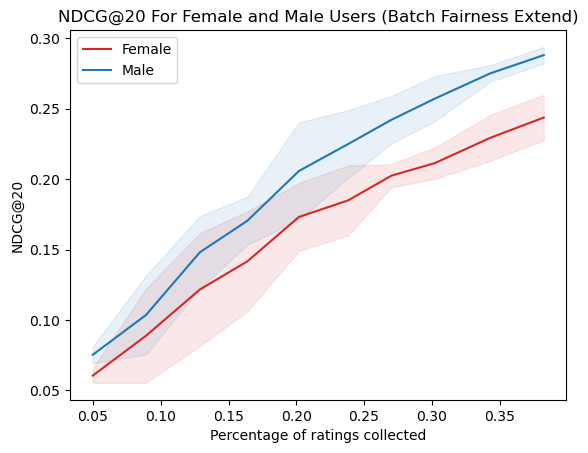

In [ ]:
# ndcg
pro_df_grouped = FE_results_df.groupby('epoch').agg(['mean', 'std', 'count'])['ndcg_pro']
pro_df_grouped['ci'] = 1.95 * pro_df_grouped['std'] / np.sqrt(pro_df_grouped['count'])
pro_df_grouped['ci_lower'] = pro_df_grouped['mean'] - pro_df_grouped['ci']
pro_df_grouped['ci_upper'] = pro_df_grouped['mean'] + pro_df_grouped['ci']

unpro_df_grouped = FE_results_df.groupby('epoch').agg(['mean', 'std', 'count'])['ndcg_unpro']
unpro_df_grouped['ci'] = 1.95 * unpro_df_grouped['std'] / np.sqrt(unpro_df_grouped['count'])
unpro_df_grouped['ci_lower'] = unpro_df_grouped['mean'] - unpro_df_grouped['ci']
unpro_df_grouped['ci_upper'] = unpro_df_grouped['mean'] + unpro_df_grouped['ci']

plt.plot(percentages, pro_df_grouped['mean'], color='tab:red', label="Female")
plt.fill_between(
    percentages,
    pro_df_grouped['ci_lower'],
    pro_df_grouped['ci_upper'],
    color='tab:red',
    alpha=.1
)

plt.plot(percentages, unpro_df_grouped['mean'], color='tab:blue', label="Male")
plt.fill_between(
    percentages,
    unpro_df_grouped['ci_lower'],
    unpro_df_grouped['ci_upper'],
    color='tab:blue',
    alpha=.1
)

plt.xlabel('Percentage of ratings collected')
plt.ylabel('NDCG@20')

plt.legend()
plt.title("NDCG@20 For Female and Male Users (Batch Fairness Extend)")
plt.show()

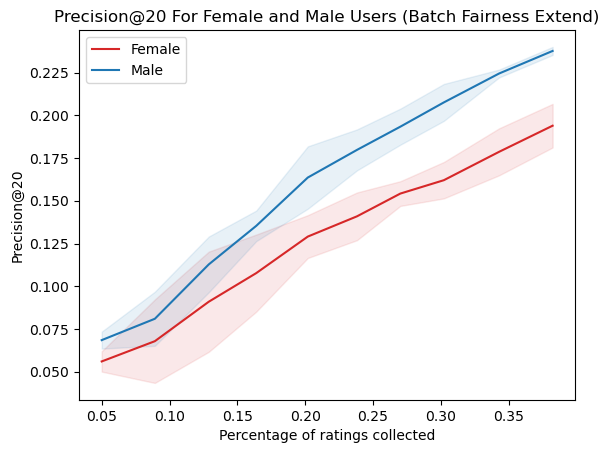

In [ ]:
# precision
pro_df_grouped = FE_results_df.groupby('epoch').agg(['mean', 'std', 'count'])['precision_pro']
pro_df_grouped['ci'] = 1.95 * pro_df_grouped['std'] / np.sqrt(pro_df_grouped['count'])
pro_df_grouped['ci_lower'] = pro_df_grouped['mean'] - pro_df_grouped['ci']
pro_df_grouped['ci_upper'] = pro_df_grouped['mean'] + pro_df_grouped['ci']

unpro_df_grouped = FE_results_df.groupby('epoch').agg(['mean', 'std', 'count'])['precision_unpro']
unpro_df_grouped['ci'] = 1.95 * unpro_df_grouped['std'] / np.sqrt(unpro_df_grouped['count'])
unpro_df_grouped['ci_lower'] = unpro_df_grouped['mean'] - unpro_df_grouped['ci']
unpro_df_grouped['ci_upper'] = unpro_df_grouped['mean'] + unpro_df_grouped['ci']

plt.plot(percentages, pro_df_grouped['mean'], color='tab:red', label="Female")
plt.fill_between(
    percentages,
    pro_df_grouped['ci_lower'],
    pro_df_grouped['ci_upper'],
    color='tab:red',
    alpha=.1
)

plt.plot(percentages, unpro_df_grouped['mean'], color='tab:blue', label="Male")
plt.fill_between(
    percentages,
    unpro_df_grouped['ci_lower'],
    unpro_df_grouped['ci_upper'],
    color='tab:blue',
    alpha=.1
)

plt.xlabel('Percentage of ratings collected')
plt.ylabel('Precision@20')

plt.legend()
plt.title("Precision@20 For Female and Male Users (Batch Fairness Extend)")
plt.show()

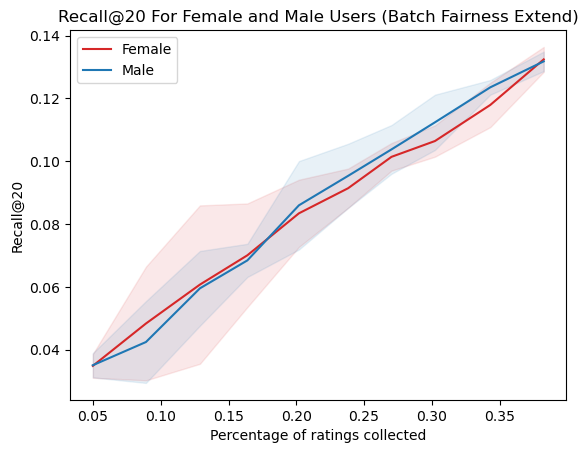

In [ ]:
# recall
pro_df_grouped = FE_results_df.groupby('epoch').agg(['mean', 'std', 'count'])['recall_pro']
pro_df_grouped['ci'] = 1.95 * pro_df_grouped['std'] / np.sqrt(pro_df_grouped['count'])
pro_df_grouped['ci_lower'] = pro_df_grouped['mean'] - pro_df_grouped['ci']
pro_df_grouped['ci_upper'] = pro_df_grouped['mean'] + pro_df_grouped['ci']

unpro_df_grouped = FE_results_df.groupby('epoch').agg(['mean', 'std', 'count'])['recall_unpro']
unpro_df_grouped['ci'] = 1.95 * unpro_df_grouped['std'] / np.sqrt(unpro_df_grouped['count'])
unpro_df_grouped['ci_lower'] = unpro_df_grouped['mean'] - unpro_df_grouped['ci']
unpro_df_grouped['ci_upper'] = unpro_df_grouped['mean'] + unpro_df_grouped['ci']

plt.plot(percentages, pro_df_grouped['mean'], color='tab:red', label="Female")
plt.fill_between(
    percentages,
    pro_df_grouped['ci_lower'],
    pro_df_grouped['ci_upper'],
    color='tab:red',
    alpha=.1
)

plt.plot(percentages, unpro_df_grouped['mean'], color='tab:blue', label="Male")
plt.fill_between(
    percentages,
    unpro_df_grouped['ci_lower'],
    unpro_df_grouped['ci_upper'],
    color='tab:blue',
    alpha=.1
)

plt.xlabel('Percentage of ratings collected')
plt.ylabel('Recall@20')

plt.legend()
plt.title("Recall@20 For Female and Male Users (Batch Fairness Extend)")
plt.show()

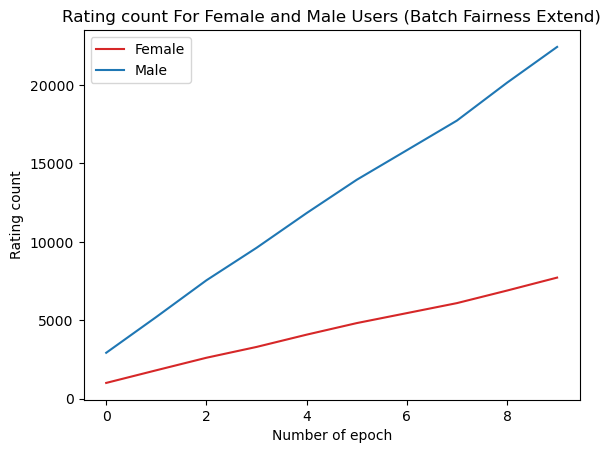

In [ ]:
# count
pro_df_grouped = FE_results_df.groupby('epoch').agg(['mean', 'std', 'count'])['count_pro']
pro_df_grouped['ci'] = 1.95 * pro_df_grouped['std'] / np.sqrt(pro_df_grouped['count'])
pro_df_grouped['ci_lower'] = pro_df_grouped['mean'] - pro_df_grouped['ci']
pro_df_grouped['ci_upper'] = pro_df_grouped['mean'] + pro_df_grouped['ci']

unpro_df_grouped = FE_results_df.groupby('epoch').agg(['mean', 'std', 'count'])['count_unpro']
unpro_df_grouped['ci'] = 1.95 * unpro_df_grouped['std'] / np.sqrt(unpro_df_grouped['count'])
unpro_df_grouped['ci_lower'] = unpro_df_grouped['mean'] - unpro_df_grouped['ci']
unpro_df_grouped['ci_upper'] = unpro_df_grouped['mean'] + unpro_df_grouped['ci']

plt.plot(np.arange(n_epochs), pro_df_grouped['mean'], color='tab:red', label="Female")

plt.plot(np.arange(n_epochs), unpro_df_grouped['mean'], color='tab:blue', label="Male")

plt.xlabel('Number of epoch')
plt.ylabel('Rating count')

plt.legend()
plt.title("Rating count For Female and Male Users (Batch Fairness Extend)")
plt.show()

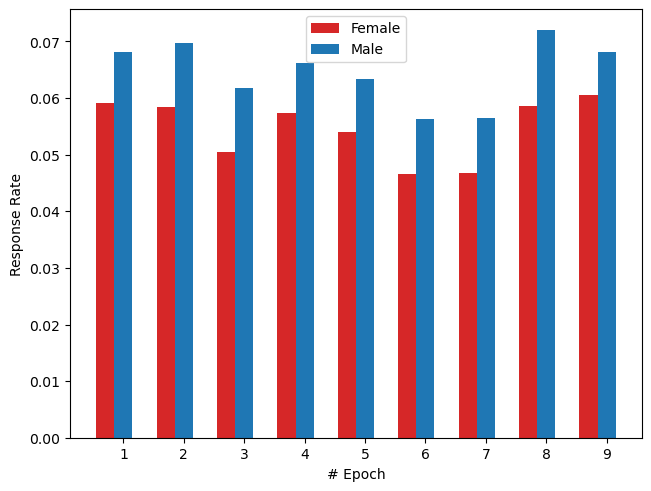

In [ ]:
# response rate
count_df = FE_results_df[['epoch', 'count_pro', 'count_unpro']]
mean_count_df = count_df.groupby('epoch').agg('mean')
collected_count_df = mean_count_df.diff()
collected_count_df = collected_count_df.iloc[1:]

collected_count_df['rate_pro'] = collected_count_df['count_pro'] / (q * n_female)
collected_count_df['rate_unpro'] = collected_count_df['count_unpro'] / (q * n_male)

x = np.arange(1, n_epochs)
width = 0.3
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for col, label, c in zip(['rate_pro', 'rate_unpro'], ['Female', 'Male'], ['tab:red', 'tab:blue']):
    offset = width * multiplier
    rects = ax.bar(x + offset, collected_count_df[col], width, label=label, color=c)
    multiplier += 1

ax.set_ylabel('Response Rate')
ax.set_xlabel('# Epoch')
ax.set_xticks(x + width, x)
ax.legend()

plt.show()